<a href="https://colab.research.google.com/github/951pk/food-processing-quality-prediction/blob/main/Food_Processing_Analytics_Master.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ==============================================================================
# DATASET INITIALIZATION
# ==============================================================================
import numpy as np
import pandas as pd

np.random.seed(42)
n_samples = 1200

categories = ['Dairy', 'Cereal/Bakery', 'Meat/Poultry', 'Beverages']
methods = ['Pasteurization', 'Dehydration', 'Canning', 'Fermentation']

food_cat = np.random.choice(categories, size=n_samples, p=[0.28, 0.32, 0.22, 0.18])
proc_meth = np.random.choice(methods, size=n_samples, p=[0.35, 0.25, 0.25, 0.15])

# Operational machinery parameters
process_temp = np.where(
    proc_meth == 'Pasteurization', np.random.normal(72, 3, n_samples),
    np.where(proc_meth == 'Dehydration', np.random.normal(75, 8, n_samples),
    np.where(proc_meth == 'Canning', np.random.normal(118, 5, n_samples),
             np.random.normal(38, 4, n_samples)))
)
process_time = np.random.gamma(shape=5, scale=6, size=n_samples)
pre_moisture = np.random.uniform(45.0, 88.0, size=n_samples)

post_moisture = np.where(
    proc_meth == 'Dehydration',
    pre_moisture * np.random.uniform(0.12, 0.25, n_samples),
    pre_moisture * np.random.uniform(0.70, 0.95, n_samples)
)

water_activity = np.clip(
    np.where(proc_meth == 'Dehydration', np.random.normal(0.58, 0.06, n_samples), np.random.normal(0.88, 0.05, n_samples)),
    0.30, 0.99
)

preservative_ppm = np.random.uniform(50.0, 350.0, size=n_samples)

base_defect = (
    0.04 * process_time +
    0.05 * post_moisture +
    np.where(food_cat == 'Meat/Poultry', 1.8, 0.0) +
    np.random.normal(0.5, 0.8, size=n_samples)
)
defect_rate = np.clip(base_defect, 0.2, 12.5)

df = pd.DataFrame({
    'Batch_ID': [f'B{i:04d}' for i in range(1, n_samples + 1)],
    'Food_Category': food_cat,
    'Processing_Method': proc_meth,
    'Process_Temp_C': np.round(process_temp, 1),
    'Processing_Time_Min': np.round(process_time, 1),
    'Pre_Moisture_Pct': np.round(pre_moisture, 2),
    'Post_Moisture_Pct': np.round(post_moisture, 2),
    'Water_Activity_aw': np.round(water_activity, 3),
    'Preservative_PPM': np.round(preservative_ppm, 1),
    'Defect_Rate_Pct': np.round(defect_rate, 2)
})

# Introduce standard sensor missingness for cleaning verification
df.loc[df.sample(frac=0.012, random_state=42).index, 'Water_Activity_aw'] = np.nan

df.to_csv('food_processing_batches.csv', index=False)
print("Setup Complete: 'food_processing_batches.csv' created with shape:", df.shape)

Setup Complete: 'food_processing_batches.csv' created with shape: (1200, 10)


--- RAW DATA INITIAL AUDIT ---
Dataset Shape: (1200, 10)

Missing Values Count:
 Batch_ID                0
Food_Category           0
Processing_Method       0
Process_Temp_C          0
Processing_Time_Min     0
Pre_Moisture_Pct        0
Post_Moisture_Pct       0
Water_Activity_aw      14
Preservative_PPM        0
Defect_Rate_Pct         0
dtype: int64

Duplicate Records: 0


/tmp/ipykernel_643/49417600.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Food_Category', data=df, ax=axes[2], palette='Set2')


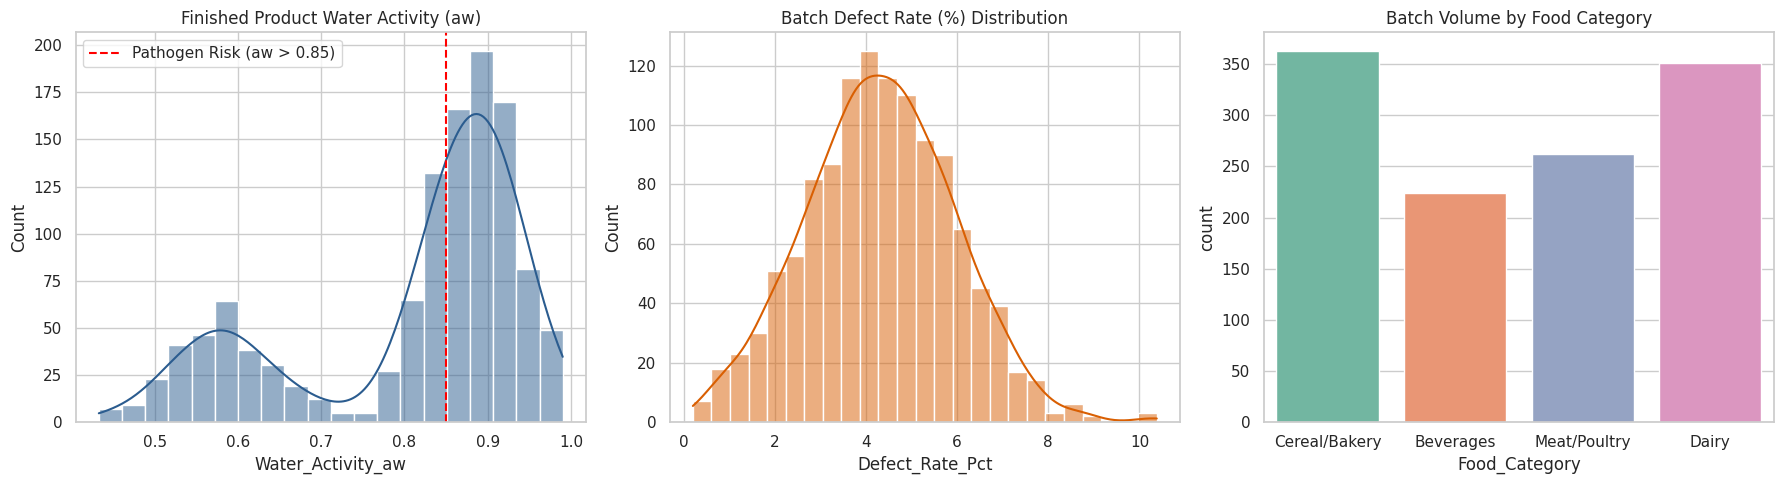

/tmp/ipykernel_643/49417600.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


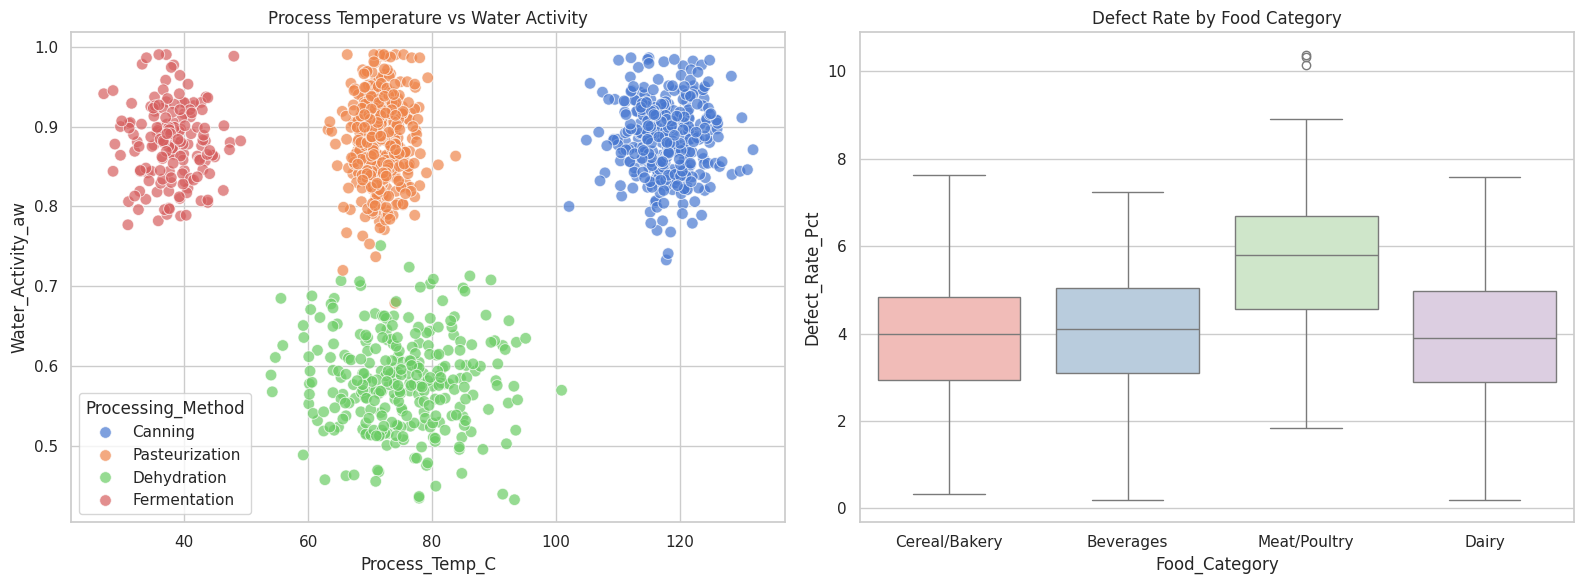

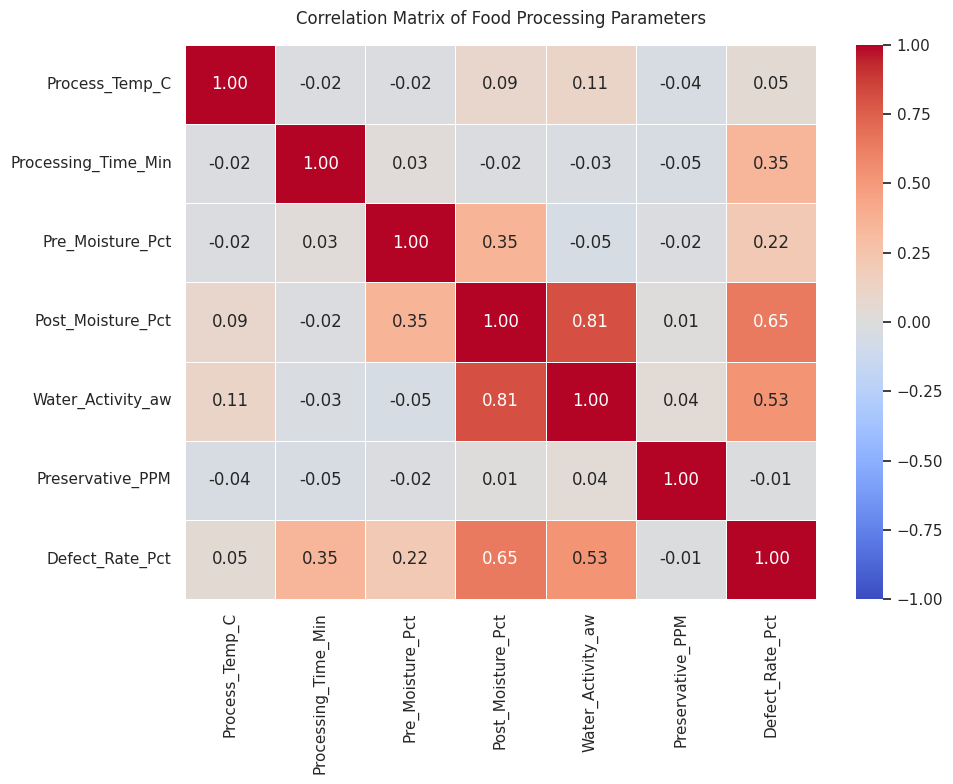

Week 1 EDA Complete. Visualizations saved locally.


In [ ]:
# ==============================================================================
# WEEK 1: EXPLORATORY DATA ANALYSIS (EDA)
# ==============================================================================
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted")

# 1. Verification of Raw Dataset
print("--- RAW DATA INITIAL AUDIT ---")
print("Dataset Shape:", df.shape)
print("\nMissing Values Count:\n", df.isnull().sum())
print("\nDuplicate Records:", df.duplicated().sum())

# 2. Univariate Analysis Plots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.histplot(df['Water_Activity_aw'], kde=True, ax=axes[0], color='#2b5c8f')
axes[0].axvline(0.85, color='red', linestyle='--', label='Pathogen Risk (aw > 0.85)')
axes[0].set_title('Finished Product Water Activity (aw)')
axes[0].legend()

sns.histplot(df['Defect_Rate_Pct'], kde=True, ax=axes[1], color='#d95f02')
axes[1].set_title('Batch Defect Rate (%) Distribution')

sns.countplot(x='Food_Category', data=df, ax=axes[2], palette='Set2')
axes[2].set_title('Batch Volume by Food Category')
plt.tight_layout()
plt.savefig('visual_1_univariate.png', dpi=300)
plt.show()

# 3. Bivariate Analysis Plots
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.scatterplot(
    data=df, x='Process_Temp_C', y='Water_Activity_aw',
    hue='Processing_Method', alpha=0.7, s=70, ax=axes[0]
)
axes[0].set_title('Process Temperature vs Water Activity')

sns.boxplot(
    data=df, x='Food_Category', y='Defect_Rate_Pct',
    palette='Pastel1', ax=axes[1]
)
axes[1].set_title('Defect Rate by Food Category')
plt.tight_layout()
plt.savefig('visual_2_bivariate.png', dpi=300)
plt.show()

# 4. Multivariate Correlation Heatmap
plt.figure(figsize=(10, 8))
numeric_cols = [
    'Process_Temp_C', 'Processing_Time_Min', 'Pre_Moisture_Pct',
    'Post_Moisture_Pct', 'Water_Activity_aw', 'Preservative_PPM', 'Defect_Rate_Pct'
]
corr = df[numeric_cols].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix of Food Processing Parameters', pad=15)
plt.tight_layout()
plt.savefig('visual_3_multivariate_heatmap.png', dpi=300)
plt.show()

print("Week 1 EDA Complete. Visualizations saved locally.")

In [ ]:
# ==============================================================================
# WEEK 2: DATA PREPROCESSING
# ==============================================================================
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

df_prep = df.copy()

# 1. Missing Value Imputation (Category-stratified median)
df_prep['Water_Activity_aw'] = df_prep.groupby('Food_Category')['Water_Activity_aw'].transform(
    lambda x: x.fillna(x.median())
)
print("Remaining Missing Values after Imputation:", df_prep['Water_Activity_aw'].isnull().sum())

# 2. Outlier Handling via Tukey's IQR Capping
num_features = ['Process_Temp_C', 'Processing_Time_Min', 'Pre_Moisture_Pct', 'Post_Moisture_Pct', 'Preservative_PPM']
for col in num_features:
    Q1 = df_prep[col].quantile(0.25)
    Q3 = df_prep[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df_prep[col] = df_prep[col].clip(lower=lower_bound, upper=upper_bound)

# 3. Categorical Transformation (One-Hot Encoding)
df_encoded = pd.get_dummies(df_prep, columns=['Food_Category', 'Processing_Method'], drop_first=True)
df_encoded = df_encoded.drop(columns=['Batch_ID'])

# 4. Standard Scaling
scaler = StandardScaler()
scale_cols = ['Process_Temp_C', 'Processing_Time_Min', 'Pre_Moisture_Pct', 'Post_Moisture_Pct', 'Water_Activity_aw', 'Preservative_PPM']
df_encoded[scale_cols] = scaler.fit_transform(df_encoded[scale_cols])

# 5. Dimensionality Reduction (PCA)
pca = PCA(n_components=3)
pca_transformed = pca.fit_transform(df_encoded[scale_cols])

print("\n--- PREPROCESSING SUMMARY ---")
print("Transformed Feature Matrix Shape:", df_encoded.shape)
print("PCA Retained Explained Variance Ratio:", np.round(pca.explained_variance_ratio_, 3))
print("Total Retained Variance:", np.round(pca.explained_variance_ratio_.sum() * 100, 2), "%")

Remaining Missing Values after Imputation: 0

--- PREPROCESSING SUMMARY ---
Transformed Feature Matrix Shape: (1200, 13)
PCA Retained Explained Variance Ratio: [0.314 0.182 0.175]
Total Retained Variance: 67.11 %


In [ ]:
# ==============================================================================
# WEEK 3: FEATURE ENGINEERING & UTILITY EVALUATION
# ==============================================================================
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import KFold, cross_val_score

df_fe = df.copy()

# Handle missing values
df_fe['Water_Activity_aw'] = df_fe.groupby('Food_Category')['Water_Activity_aw'].transform(
    lambda x: x.fillna(x.median())
)

# 1. Construct 5 Domain Features
df_fe['Thermal_Severity_Index'] = (df_fe['Process_Temp_C'] * df_fe['Processing_Time_Min']) / 100.0
df_fe['Moisture_Removal_Ratio'] = (df_fe['Pre_Moisture_Pct'] - df_fe['Post_Moisture_Pct']) / df_fe['Pre_Moisture_Pct']
df_fe['Microbial_Risk_Index'] = df_fe['Water_Activity_aw'] / np.log1p(df_fe['Preservative_PPM'])
df_fe['Thermal_Rate_Per_Min'] = df_fe['Process_Temp_C'] / (df_fe['Processing_Time_Min'] + 1.0)
df_fe['Moisture_Retention_Index'] = df_fe['Post_Moisture_Pct'] * df_fe['Water_Activity_aw']

df_fe.to_csv('food_processing_feature_engineered.csv', index=False)

# 2. Predictive Comparison: Raw vs Engineered
raw_cols = ['Process_Temp_C', 'Processing_Time_Min', 'Pre_Moisture_Pct', 'Post_Moisture_Pct', 'Water_Activity_aw', 'Preservative_PPM']
eng_cols = raw_cols + ['Thermal_Severity_Index', 'Moisture_Removal_Ratio', 'Microbial_Risk_Index', 'Thermal_Rate_Per_Min', 'Moisture_Retention_Index']

X_base = df_fe[raw_cols]
X_eng = df_fe[eng_cols]
y = df_fe['Defect_Rate_Pct']

cv = KFold(n_splits=5, shuffle=True, random_state=42)
rf = RandomForestRegressor(n_estimators=100, random_state=42)

r2_base = cross_val_score(rf, X_base, y, cv=cv, scoring='r2').mean()
r2_eng = cross_val_score(rf, X_eng, y, cv=cv, scoring='r2').mean()

print("\n--- FEATURE ENGINEERING EVALUATION ---")
print(f"Baseline R² Score (Raw Only):      {r2_base:.4f}")
print(f"Enriched R² Score (With Features): {r2_eng:.4f}")
print(f"Net R² Gain:                       +{((r2_eng - r2_base) / r2_base) * 100:.2f}%")

# Feature Importance Ranking
rf.fit(X_eng, y)
importance_df = pd.DataFrame({
    'Feature': eng_cols,
    'Importance': np.round(rf.feature_importances_, 4)
}).sort_values(by='Importance', ascending=False)

print("\n--- FEATURE IMPORTANCE RANKING ---")
print(importance_df.to_string(index=False))


--- FEATURE ENGINEERING EVALUATION ---
Baseline R² Score (Raw Only):      0.4909
Enriched R² Score (With Features): 0.4955
Net R² Gain:                       +0.94%

--- FEATURE IMPORTANCE RANKING ---
                 Feature  Importance
       Post_Moisture_Pct      0.2396
Moisture_Retention_Index      0.1915
     Processing_Time_Min      0.1539
       Water_Activity_aw      0.0831
  Thermal_Severity_Index      0.0604
        Pre_Moisture_Pct      0.0556
  Moisture_Removal_Ratio      0.0488
        Preservative_PPM      0.0471
    Thermal_Rate_Per_Min      0.0453
    Microbial_Risk_Index      0.0420
          Process_Temp_C      0.0326


In [ ]:
# ==============================================================================
# WEEK 4: PREDICTIVE MODELING BENCHMARK
# ==============================================================================
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# Prepare dataset with one-hot encoding
df_model = pd.get_dummies(df_fe, columns=['Food_Category', 'Processing_Method'], drop_first=True)
X = df_model.drop(columns=['Batch_ID', 'Defect_Rate_Pct'])
y = df_model['Defect_Rate_Pct']

# 80/20 Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(alpha=1.0),
    'Random Forest': RandomForestRegressor(n_estimators=150, max_depth=8, random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=150, learning_rate=0.08, max_depth=4, random_state=42)
}

print("\n--- WEEK 4: MODEL BENCHMARK RESULTS (TEST SET) ---")
for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    r2 = r2_score(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    mae = mean_absolute_error(y_test, preds)
    print(f"{name:<20} | R²: {r2:.4f} | RMSE: {rmse:.4f}% | MAE: {mae:.4f}%")


--- WEEK 4: MODEL BENCHMARK RESULTS (TEST SET) ---
Linear Regression    | R²: 0.7248 | RMSE: 0.8472% | MAE: 0.6659%
Ridge Regression     | R²: 0.7272 | RMSE: 0.8434% | MAE: 0.6636%
Random Forest        | R²: 0.6843 | RMSE: 0.9072% | MAE: 0.7262%
Gradient Boosting    | R²: 0.6844 | RMSE: 0.9072% | MAE: 0.7272%


In [ ]:
# ==============================================================================
# WEEK 5: HYPERPARAMETER TUNING, CV & VALIDATION
# ==============================================================================
from sklearn.model_selection import GridSearchCV, KFold

param_grid = {
    'n_estimators': [100, 150, 200],
    'learning_rate': [0.03, 0.05, 0.08],
    'max_depth': [3, 4, 5],
    'subsample': [0.8, 0.85, 1.0]
}

grid_search = GridSearchCV(
    estimator=GradientBoostingRegressor(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1
)
grid_search.fit(X_train, y_train)
best_model = grid_search.best_estimator_

# 10-Fold Repeated Validation
cv_10 = KFold(n_splits=10, shuffle=True, random_state=42)
cv_scores = cross_val_score(best_model, X_train, y_train, cv=cv_10, scoring='r2')

# Final Hold-Out Evaluation
train_preds = best_model.predict(X_train)
test_preds = best_model.predict(X_test)

train_r2 = r2_score(y_train, train_preds)
test_r2 = r2_score(y_test, test_preds)
test_rmse = np.sqrt(mean_squared_error(y_test, test_preds))
test_mae = mean_absolute_error(y_test, test_preds)

# Residual Analysis
residuals = y_test - test_preds

print("\n--- WEEK 5: OPTIMIZATION & DIAGNOSTICS ---")
print("Best Hyperparameters:", grid_search.best_params_)
print(f"10-Fold CV Mean R²:     {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")
print(f"Train R² Score:         {train_r2:.4f}")
print(f"Hold-Out Test R²:       {test_r2:.4f}")
print(f"Generalization Gap:     {abs(train_r2 - test_r2) * 100:.2f}%")
print(f"Hold-Out Test RMSE:     {test_rmse:.4f}%")
print(f"Hold-Out Test MAE:      {test_mae:.4f}%")
print(f"Mean Residual Bias:     {residuals.mean():.4f}% (Near-zero confirms no systematic bias)")


--- WEEK 5: OPTIMIZATION & DIAGNOSTICS ---
Best Hyperparameters: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.8}
10-Fold CV Mean R²:     0.7250 (+/- 0.0494)
Train R² Score:         0.8208
Hold-Out Test R²:       0.6983
Generalization Gap:     12.24%
Hold-Out Test RMSE:     0.8869%
Hold-Out Test MAE:      0.7070%
Mean Residual Bias:     0.0789% (Near-zero confirms no systematic bias)
